In [1]:
import os
import random
import ast
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
import numpy as np
from matplotlib.patches import Rectangle, Patch
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

def get_base_data(genus_name, label):
    base_folder = f'/active-data/analysis_results/chr_pla/genus'
    folder = f'{base_folder}/statistics_records/{genus_name}'
    figure_fold = f'{base_folder}/figures'
    os.makedirs(figure_fold, exist_ok=True)
    os.chdir(folder)

    fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    df = fraction_data.rename(columns={
        f'average plasmid fraction-{label}': 'plasmidness',
        'size': 'size'
    })

    prediction_re = pd.read_csv("./annotations/NMS_replicon_type_prediction_results.csv")
    prediction_re = prediction_re[prediction_re[f'category-{label}'].isin(['typical plasmid', 'intermediate replicon'])]
    return base_folder, folder, figure_fold, df, prediction_re, fraction_data

In [2]:
def get_selected_sequences(df, label):
    size_target = 1e5
    size_tol = 0.3
    group1 = df[(df['size'].between(size_target*(1-size_tol), size_target*(1+size_tol))) & (df['plasmidness'] > 0.8)]
    group2 = df[(df['size'].between(size_target*(1-size_tol), size_target*(1+size_tol))) & (df['plasmidness'].between(0.35, 0.45))]
    group3 = df[(df['size'].between(size_target*(1-size_tol), size_target*(1+size_tol))) & (df['plasmidness'] < 0.1)]
    group4 = df[df['size'] > 1e6]

    selected1 = group1.sample(1, random_state=42) if not group1.empty else None
    selected2 = group2.sample(1, random_state=42) if not group2.empty else None
    selected3 = group3.sample(1, random_state=3) if not group3.empty else None
    selected4 = group4.sample(1, random_state=42) if not group4.empty else None
    selected_list = [selected1, selected2, selected3, selected4]

    query_list = []
    for s in selected_list:
        query_list.append(s['accession'].values[0] if s is not None else None)
    return selected_list, query_list

def get_scatter_data(df, fraction_data, label):
    threshold = 0.3
    def process_replicon_data(fraction_data):
        typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
        min_size = min(typ_chr['size'])
        tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
        return min_size * 0.5 if tra_rep.empty else (min_size + max(tra_rep['size']))/2
    size_split = process_replicon_data(fraction_data)
    x = df['size']
    y = df['plasmidness']
    threshold_plasmidness = 0.3
    group_plasmid = df[df['plasmidness'] >= threshold_plasmidness]
    group_trans = df[(df['plasmidness'] < threshold_plasmidness) & (df['size'] < size_split)]
    group_chr = df[(df['plasmidness'] < threshold_plasmidness) & (df['size'] > size_split)]
    return x, y, threshold, size_split, group_plasmid, group_trans, group_chr

def plot_scatter(ax, data, selected_list, genus_name, font_prop, ifont_prop):
    x, y, threshold, size_split, group_plasmid, group_trans, group_chr = data
    x_min, x_max, y_min, y_max = 100, 5e7, -0.03, 1.03
    n_plasmid, n_trans, n_chr = len(group_plasmid), len(group_trans), len(group_chr)

    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)

    ax.text(4.9e7, threshold+0.01, f'Typical plasmid\n(n={n_plasmid})', color='#0056b0', va='bottom', ha='right', zorder=5)
    ax.text(120, threshold-0.01, f'Intermediate replicon\n(IR, n={n_trans})', color='#006622', va='top', ha='left', zorder=5)
    ax.text(4.9e7, threshold-0.01, f'Typical chromosome\n(n={n_chr})', color='#d86f16', va='top', ha='right', zorder=5)

    ax.scatter(x, y, marker='o', s=3, c='gray', zorder=3, edgecolors='none')
    colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
    for i, s in enumerate(selected_list):
        if s is not None:
            ax.scatter(s['size'], s['plasmidness'], color=colors[i], s=30, edgecolor='black', linewidth=0.8, zorder=5)

    ax.axhline(y=threshold, color='gray', linestyle='--', lw=0.8)
    ax.text(50, threshold, '0.3', va='center', color='gray')
    ax.set_xlabel('Size / bp')
    ax.set_ylabel('Plasmidness')
    ax.set_xscale('log')
    ax.set_title(genus_name, fontproperties=ifont_prop, fontsize=8, pad=3)
    ax.set_xlim(100, 5e7)
    ax.set_ylim(y_min, y_max)

def get_curve_data(query_list, base_folder, genus_name, label):
    curve_data_list = []
    for query_acc in query_list:
        if not query_acc:
            curve_data_list.append(None)
            continue
        try:
            acc_n, replicon = query_acc.split('-')[0], query_acc.split('-')[1]
            file_path = f'{base_folder}/cor-pla_fraction_records/{genus_name}/{acc_n}/{replicon}.txt'
            with open(file_path) as f:
                for line in f:
                    dic_p = ast.literal_eval(line)
                    list_key = list(dic_p.keys())[1]
                    if label in list_key:
                        x_plot = [s*200-100 for s in range(len(dic_p[list_key]))]
                        y_plot = dic_p[list_key]
                        mean_val = dic_p[list(dic_p.keys())[0]]
                        curve_data_list.append((x_plot, y_plot, mean_val, query_acc))
                        break
        except:
            curve_data_list.append(None)
    return curve_data_list

def plot_curves(axes, curve_data_list):
    title_colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
    for ax, data, color in zip(axes, curve_data_list, title_colors):
        if not data:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        x, y, mean_val, acc = data
        ax.plot(x, y, lw=1, color='#1f77b4')
        ax.axhline(mean_val, c='r', ls='--', lw=0.5, label=f'Plasmidness={mean_val:.3f}')
        ax.set_ylim(-0.1, 1.1)
        ax.legend()
        ax.set_ylabel("Plasmid\nfraction")
        ax.set_title(f'• {acc}', color=color, pad=3)
    axes[-1].set_xlabel("Nucleotide sequence / bp")

def plot_connections(fig, ax_scatter, curve_axes, selected_list):
    dark_colors = ['#d63031', '#e17055', '#0984e3', '#00b894']
    for s, ax_c, color in zip(selected_list, curve_axes, dark_colors):
        if s is None: continue
        x_p, y_p = s['size'].values[0], s['plasmidness'].values[0]
        con = ConnectionPatch(xyA=(x_p,y_p), coordsA=ax_scatter.transData,
                             xyB=(0,0.5), coordsB=ax_c.transAxes,
                             arrowstyle='->', shrinkA=8, shrinkB=3,
                             mutation_scale=12, lw=1.2, color=color, zorder=10)
        fig.add_artist(con)

In [3]:
def get_heatmap_data(prediction_re, label):
    df_rename = prediction_re.copy()
    cols = ['initial_type','plasflow_pdc','plasmer_pdc','rfplasmid_pdc','deeplasmid_pdc']
    df_sort = df_rename.sort_values(f'average plasmid fraction-{label}', ascending=True).reset_index(drop=True)
    score = df_sort[f'average plasmid fraction-{label}'].values
    score500 = score[:500]
    threshold = 0.3
    th_idx = (score >= threshold).argmax()
    df_num = df_sort[cols].map(lambda x:1 if x=='plasmid' else 2 if x=='chromosome' else 0).T
    df_num500 = df_num.iloc[:,:500]
    return cols, score, score500, th_idx, df_num, df_num500

def plot_heatmap(ax, data, title, cols, th_idx):
    n_tools, n_seqs = data.shape
    c_base, c_chr, c_unc, lc = '#cce7ff', '#ff962d', '#b0b0b0', 'red'
    ax.add_patch(Rectangle((0,0),n_seqs,n_tools,facecolor=c_base,zorder=1))
    for i in range(n_tools):
        for j in range(n_seqs):
            v = data.iloc[i,j]
            if v==2: 
                ax.add_patch(Rectangle((j,i),1,1,facecolor=c_chr,zorder=2))
            elif v==0: 
                ax.add_patch(Rectangle((j,i),1,1,facecolor=c_unc,zorder=2))
    ax.axvline(th_idx, c=lc, ls='--', lw=0.5, zorder=5)
    ax.text(th_idx, -0.15, 'Plasmidness=0.3', ha='center', c=lc)
    ax.set_xlim(0,n_seqs)
    ax.set_ylim(0,n_tools)
    ax.invert_yaxis()
    ax.set_yticks(np.arange(n_tools)+0.5)
    display_names = ['Initial_type','PlasFlow','Plasmer','RFPlasmid','Deeplasmid']
    ax.set_yticklabels(display_names)
    ax.set_xticks([])
    ax.set_title(title, pad=3)

def plot_color_bar(ax, values, cmap):
    norm = plt.Normalize(0,1)
    n = len(values)
    for i in range(n):
        color = cmap(norm(values[i]))
        h = 0.1 + (i/(n-1) if n>1 else 1)*0.9
        ax.add_patch(Rectangle((i,0),1,h,color=color,lw=0))
    ax.set_xlim(0,n)
    ax.set_ylim(0,1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0, 0.5, 'Plasmidness', ha='right', va='center')
    ax.spines[:].set_visible(False)

def plot_arrow_bar(ax, values):
    n = len(values)
    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.annotate(
        "",
        xy=(n, 0.8),
        xytext=(0, 0.8),
        arrowprops=dict(arrowstyle="->", lw=1.5, color="black", shrinkA=0, shrinkB=0)
    )
    ax.text((0 + n)/2, 0.68, "Increasing plasmidness", ha="center", va="top")
    ax.spines[:].set_visible(False)

def plot_label_band(ax, th_idx, total, color_t, color_p):
    ax.add_patch(Rectangle((0, 0), min(th_idx, total), 1, facecolor=color_t))
    ax.add_patch(Rectangle((min(th_idx, total), 0), total-min(th_idx, total), 1, facecolor=color_p))
    ax.set_xlim(0, total)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)
    ax.text(min(th_idx, total)/2, -0.1, 'IR', ha='center', va='top', c='#006622')
    ax.text(min(th_idx, total)+(total-min(th_idx, total))/2, -0.1, 'Typical plasmid', ha='center', va='top', c='#0056b0')

def get_consistency_data(df_renamed, label):
    threshold = 0.3
    tools_raw = ['initial_type', 'plasflow_pdc', 'plasmer_pdc', 'rfplasmid_pdc', 'deeplasmid_pdc']
    
    low = df_renamed[df_renamed[f'category-{label}']=='intermediate replicon']
    high = df_renamed[df_renamed[f'category-{label}']=='typical plasmid']
    
    def consistent(df):
        total = len(df)
        if total == 0:
            return 0
        cnt = len(df[df[tools_raw].nunique(axis=1)==1])
        return cnt/total*100
    
    return [consistent(low), consistent(high)]

def plot_consistency_bar(ax, data):
    groups = ['IR','Typical\nplasmid']
    colors = ['#a5d6a5','#7fb8f5']
    bars = ax.bar(groups, data, color=colors, width=0.8, ec='black', lw=0)
    for b,v in zip(bars,data):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%', ha='center', )
    ax.set_ylabel('Replicon percentage (%)', labelpad=0)
    ax.set_title('Annotation consistency', pad=3)
    ax.set_ylim(0,100)

def get_anno_comp_data(df_renamed, label, cate='Trans_rep'):
    threshold = 0.3
    tools_raw = ['initial_type', 'plasflow_pdc', 'plasmer_pdc', 'rfplasmid_pdc', 'deeplasmid_pdc']
    tools_display = ['Initial_type', 'PlasFlow', 'Plasmer', 'RFPlasmid', 'Deeplasmid']
    
    if cate == 'Trans_rep':
        temp_data = df_renamed[df_renamed[f'category-{label}']=='intermediate replicon']
    elif cate == 'Typ_pla':
        temp_data = df_renamed[df_renamed[f'category-{label}']=='typical plasmid']
    res = {}
    for t_raw, t_disp in zip(tools_raw, tools_display):
        pred = temp_data[t_raw].str.strip().str.lower()
        p = (pred == 'plasmid').sum()
        c = (pred == 'chromosome').sum()
        u = (pred == 'unclassified').sum()
        total = p + c + u or 1
        res[t_disp] = (p/total*100, c/total*100, u/total*100)
    return tools_display, res

def plot_anno_comp(ax, tools, data, title='Intermediate replicon', title_color='#006622'):
    cp, cc, cu = '#cce7ff', '#ff962d', '#b0b0b0'
    y = np.arange(len(tools))
    p = [data[t][0] for t in tools]
    c = [data[t][1] for t in tools]
    u = [data[t][2] for t in tools]
    
    ax.barh(y, p, 0.85, color=cp, ec='black', lw=0.6)
    ax.barh(y, c, 0.85, left=p, color=cc, ec='black', lw=0.6)
    ax.barh(y, u, 0.85, left=np.add(p, c), color=cu, ec='black', lw=0.6)
    
    for i, (pi, ci, ui) in enumerate(zip(p, c, u)):
        if pi > 8:
            ax.text(pi / 2, i, f'{pi:.1f}%', ha='center', va='center')
        if ci > 8:
            ax.text(pi + ci / 2, i, f'{ci:.1f}%', ha='center', va='center')
        if ui > 8:
            ax.text(pi + ci + ui / 2, i, f'{ui:.1f}%', ha='center', va='center')
    
    ax.set_yticks(y)
    ax.set_yticklabels(tools)
    ax.invert_yaxis()
    ax.set_xlabel('Annotation composition (%)', labelpad=0)
    ax.set_xlim(0, 100)
    ax.set_title(title, color=title_color, pad=3)

In [4]:
import ast
import os
import pandas as pd
import textract

# chromid reference data

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID20080407/1-s2.0-S0966842X09002698-mmc1.doc"
content = textract.process(file_path, encoding="utf-8")
content = content.decode("utf-8")

ref1_list = []
for line in content.splitlines():
    if "Chromid" in line and '|' in line:
        parts = line.split("|")
        nc_code = parts[4].strip()
        ref1_list.append(nc_code.replace(' ', '_'))

file_path = "/active-data/analysis_results/chr_pla/reference_data/PMID40827884/msystems.00175-25-s0003.xlsx"

df = pd.read_excel(file_path, skiprows=1)
chromid_ref = df[df['GC_difference_%'] != 0]
ref2_list = chromid_ref['Replicon_Accession'].to_list()

# chromid-finder data

def extract_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
filted_data = all_data[all_data['genus_clean'].isin(keep_genus)]

found_chromids = []
chromid_dir = '/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/chromid_results'
for acc_n in filted_data['accession']:
    file_path = f'{chromid_dir}/{acc_n}.txt'
    
    if os.path.getsize(file_path) == 0:
        continue
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
        for i, line in enumerate(lines):
            if "Possible bacterial chromids:" in line:
                if i + 1 >= len(lines):
                    continue
                chromid_line = lines[i+1].strip()
                if not chromid_line or chromid_line == '------':
                    break
                
                chromid_list = [c.strip() for c in chromid_line.split(",") if c.strip()]
                for chromid in chromid_list:
                    found_chromids.append(chromid.split('.')[0])

def chromid_info_genus(genus_name, all_chromids=set(ref1_list + ref2_list + found_chromids)):
    os.chdir(f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}')
    contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    contig_info['contig'] = contig_info['accession'].apply(
        lambda x: x.split('-')[-1].split('.')[0]
    )
    contig_s = contig_info['category-pident_90'].value_counts()
    chromid_result = contig_info[contig_info['contig'].isin(all_chromids)]
    chromid_s = chromid_result['category-pident_90'].value_counts()
    return (chromid_s/contig_s*100).fillna(0)

def plot_ratio_bar(ax, ratio_series: pd.Series, title: str = "Chromid"):
    cats = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    colors = ['#4472C4', '#70AD47', '#ED7D31']
    ratio_ordered = ratio_series.loc[cats]
    categories = ratio_ordered.index
    values = ratio_ordered.values

    bars = ax.bar(categories, values, color=colors, alpha=0.8)
    for bar, val in zip(bars, values):
        h = bar.get_height()
        if val != 0:
            val_t = val.round(3)
        else:
            val_t = 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01*max(values),
            f"{val_t}%",
            ha="center", va="bottom"
        )

    ax.set_title(title, pad=3)
    ax.set_ylabel('Replicon percentage (%)')
    ax.set_xticks(categories)
    ax.set_xticklabels(['Typical\nplasmid', 'IR', 'Typical\nchromosome'])
    ax.set_ylim(0, max(values)*1.2)

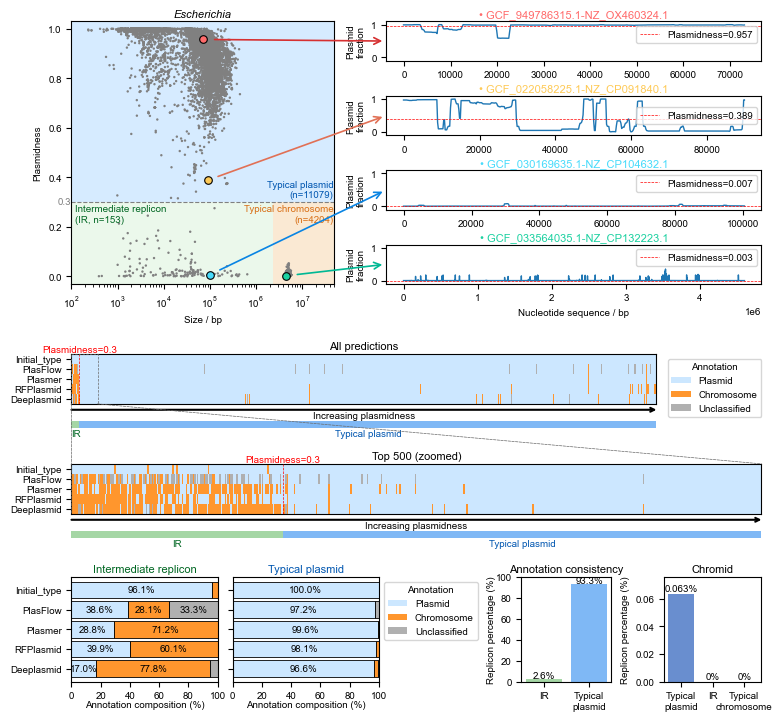

In [5]:
genus_name = 'Escherichia'
label = 'pident_90'

base_folder, folder, figure_fold, df, prediction_re, fraction_data = get_base_data(genus_name, label)
selected_list, query_list = get_selected_sequences(df, label)

fig_width = 7.5
fig_height = 7.0
fig = plt.figure(figsize=(fig_width, fig_height))

ax_scatter_width = 0.35
ax_scatter_height = ax_scatter_width*fig_width/fig_height
ax_scatter_y = 1-2.8/fig_height
ax_scatter = fig.add_axes([0.08, ax_scatter_y, ax_scatter_width, ax_scatter_height])

curve_h_space = 0.05
curve_height = (ax_scatter_height-curve_h_space*3)/4
curve_x_site = 0.5
ax_curve1 = fig.add_axes([curve_x_site, ax_scatter_y+(curve_height+curve_h_space)*3, 1-curve_x_site, curve_height])
ax_curve2 = fig.add_axes([curve_x_site, ax_scatter_y+(curve_height+curve_h_space)*2, 1-curve_x_site, curve_height])
ax_curve3 = fig.add_axes([curve_x_site, ax_scatter_y+(curve_height+curve_h_space)*1, 1-curve_x_site, curve_height])
ax_curve4 = fig.add_axes([curve_x_site, ax_scatter_y, 1-curve_x_site, curve_height])
curve_axes = [ax_curve1, ax_curve2, ax_curve3, ax_curve4]

map_up_space = 0.7/fig_height
heat_map_width = 0.98-0.2
heat_map_height = 0.5/fig_height
heat_map_inter_space = 0.6/fig_height
ax_main_y = ax_scatter_y-(heat_map_height+map_up_space)
ax_main = fig.add_axes([0.08, ax_main_y, heat_map_width, heat_map_height])
ax_zoom_y = ax_main_y-(heat_map_height+heat_map_inter_space)
ax_zoom = fig.add_axes([0.08, ax_zoom_y, 1-0.08, heat_map_height])

bar_space = 0.155/fig_height
bar_height = 0.12/fig_height
ax_main_bar = fig.add_axes([ax_main.get_position().x0, ax_main.get_position().y0-bar_space, ax_main.get_position().width, bar_height])
ax_zoom_bar = fig.add_axes([ax_zoom.get_position().x0, ax_zoom.get_position().y0-bar_space, ax_zoom.get_position().width, bar_height])

label_band_height = 0.07/fig_height
label_space = 0.02/fig_height
ax_label_main = fig.add_axes([ax_main.get_position().x0, ax_main_bar.get_position().y0 - label_band_height - label_space, ax_main.get_position().width, label_band_height])
ax_label_zoom = fig.add_axes([ax_zoom.get_position().x0, ax_zoom_bar.get_position().y0 - label_band_height - label_space, ax_zoom.get_position().width, label_band_height])

rep_y_site = ax_zoom_y - 0.24

ax_anno_comp_x = 0.08
ax_anno_comp_y = rep_y_site
ax_anno_comp_height = 0.15
ax_anno_comp1 = fig.add_axes([ax_anno_comp_x, ax_anno_comp_y, 0.195, ax_anno_comp_height])
ax_anno_comp2 = fig.add_axes([ax_anno_comp_x+0.215, ax_anno_comp_y, 0.195, ax_anno_comp_height])

ax_frac_bar_x = 0.68
ax_frac_bar_width = 0.12
ax_frac_bar_y = rep_y_site
ax_frac_bar_height = 0.15
ax_frac_bar = fig.add_axes([ax_frac_bar_x, ax_frac_bar_y, ax_frac_bar_width, ax_frac_bar_height])

ax_chromid = fig.add_axes([0.87, rep_y_site, 1-0.87, 0.15])

custom_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#00A86B","#bcbd22","#17becf"]
cm = LinearSegmentedColormap.from_list('plasmid_cmap', [custom_colors[1], '#a5d6a5', "#cce7ff"])

s_data = get_scatter_data(df, fraction_data, label)
plot_scatter(ax_scatter, s_data, selected_list, genus_name, font_prop, ifont_prop)
plot_connections(fig, ax_scatter, curve_axes, selected_list)
c_data = get_curve_data(query_list, base_folder, genus_name, label)
plot_curves(curve_axes, c_data)
cols, score, score500, th_idx, h_data, h500_data = get_heatmap_data(prediction_re, label)
plot_heatmap(ax_main, h_data, 'All predictions', cols, th_idx)
plot_heatmap(ax_zoom, h500_data, 'Top 500 (zoomed)', cols, th_idx)
#plot_color_bar(ax_main_bar, score, cm)
plot_arrow_bar(ax_main_bar, score)
#plot_color_bar(ax_zoom_bar, score500, cm)
plot_arrow_bar(ax_zoom_bar, score500)
plot_label_band(ax_label_main, th_idx, len(score), '#a5d6a5', '#7fb8f5')
plot_label_band(ax_label_zoom, th_idx, 500, '#a5d6a5', '#7fb8f5')

n_tools = len(cols)
rect_main = Rectangle((0,0),500,n_tools,lw=0.5,ec='dimgray',fc='none',linestyle='--',zorder=6)
ax_main.add_patch(rect_main)

con1 = ConnectionPatch(xyA=(0,n_tools),coordsA=ax_main.transData,xyB=(0,n_tools),coordsB=ax_zoom.transData, linestyle='--',color='dimgray',lw=0.5)
con2 = ConnectionPatch(xyA=(500,n_tools),coordsA=ax_main.transData,xyB=(500,0),coordsB=ax_zoom.transData, linestyle='--',color='dimgray',lw=0.5)
fig.add_artist(con1)
fig.add_artist(con2)

c_base, c_chr, c_unc = '#cce7ff', '#ff962d', '#b0b0b0',
legend_elements = [Patch(facecolor=c_base,label='Plasmid'), Patch(facecolor=c_chr,label='Chromosome'), Patch(facecolor=c_unc,label='Unclassified')]
annotation = fig.legend(handles=legend_elements, loc='upper left',bbox_to_anchor=(ax_main.get_position().x1,ax_main.get_position().y1),
                        title='Annotation')
fig_width_dpi = fig.get_window_extent().width
legend_right = annotation.get_window_extent().x1 / fig_width_dpi
legend_right_site = heat_map_width + 0.22
if legend_right != legend_right_site:
    overflow = legend_right - legend_right_site
    annotation.remove()
    new_x = ax_main.get_position().x1 - overflow
    annotation = fig.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(new_x, ax_main.get_position().y1),
        title='Annotation'
    )

#ax_cbar_height = 0.105/fig_height
#ax_cbar = fig.add_axes([annotation.get_window_extent().x0 / fig_width_dpi, ax_main.get_position().y1-ax_cbar_height, legend_right_site-(annotation.get_window_extent().x0 / fig_width_dpi), ax_cbar_height])
#ax_cbar.set_xlim(0, 1)
#ax_cbar.set_ylim(0, 1)
#triangle = np.array([[0, 0], [1, 0], [1, 1]])
#tri = mpatches.Polygon(triangle, facecolor='none', edgecolor='none')
#ax_cbar.add_patch(tri)
#gradient = np.linspace(0, 1, 256).reshape(1, -1)
#im = ax_cbar.imshow(gradient, cmap=cm, aspect='auto', extent=[0,1,0,1], zorder=1, alpha=1)
#im.set_clip_path(tri)
#ax_cbar.set_xlabel('Plasmidness')
#ax_cbar.spines[['top', 'bottom', 'right', 'left']].set_visible(False)
#ax_cbar.set_yticks([])

tools, comp_data1 = get_anno_comp_data(prediction_re, label)
plot_anno_comp(ax_anno_comp1, tools, comp_data1)
tools, comp_data2 = get_anno_comp_data(prediction_re, label, cate='Typ_pla')
plot_anno_comp(ax_anno_comp2, tools, comp_data2, title='Typical plasmid', title_color='#0056b0')
ax_anno_comp2.set_yticklabels([])
ax_anno_comp2.legend(handles=legend_elements, loc='upper left',bbox_to_anchor=(1,1),title='Annotation')

consist_data = get_consistency_data(prediction_re, label)
plot_consistency_bar(ax_frac_bar, consist_data)

chromid_ratio = chromid_info_genus("Escherichia")
plot_ratio_bar(ax_chromid, chromid_ratio)

os.chdir(figure_fold)
plt.savefig(f"{genus_name}_sampled_and_annotation.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{genus_name}_sampled_and_annotation.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()